# 11｜59 日调度回放与 RMSE 失败分析

**目的**：把已经冻住的 holdout RMSE v1/v2 成绩，连同官方调度回放（以为能赚 / 真正进账 / capture）放在一册里读完，并解释为什么点最准的模型不一定赚钱。

**输入**（只读，不训练）：

- `reports/holdout_rmse_v1/leaderboard.csv`、`reports/holdout_rmse_v2/leaderboard.csv`
- `reports/holdout_dispatch_replay/failure_analysis.json`
- `reports/holdout_rmse_v1/dispatch_daily.csv`、v2 同名文件
- `reports/holdout_rmse_v1/predictions.parquet`

**验收标准**：

- 35 条配方（16 v1 + 19 v2）按真正进账排序出全表；
- 四张图写入 `outputs/notebooks/figures/nb11_*.png`；
- 不改 `reports/phase_b/final_metrics.json`，不改两张 RMSE 表里已有的 RMSE/MAE；
- 不把这 59 天的利润当成新冠军选拔。

**口径**：分数是官方 `sum(price × power)`，不是人民币。`capture = realized / oracle`。Oracle 对每个模型都是同一段真价上的 3321 窗上界。


## 核心结案（先读这个）

- **真正进账第一不是 RMSE 第一。** 全场 realized 最高是 **v2 `transformer_contextual`**（日均 **6214**，capture **0.690**），它的 RMSE 只有 0.631，在 v2 表里排第 12。
- **v1 Transformer 点最准（RMSE 0.514），钱只排第 12。** 日均 realized **5637**，几乎贴着气候平均（5644）。去掉 12-30 那天的尖峰，58 日均掉到 **5196**。
- **v1 上 RMSE 和 realized 相关是 +0.33。** 点越不准，往往越能赚钱。v2 相关约 0。96 点 RMSE 不是官方分数的代理。
- **机制：光滑器压缩了峰谷。** v1 Transformer 预测日较差只有真值的 66%，价格排序 Spearman 0.61；调度只在 \(\hat p\) 上穷举 8+8，窗就坐错。v2 同结构多训之后幅度回到 0.93、Spearman 0.71，RMSE 变差，钱反而最好。
- **不要从这 59 天另选冠军。** 这段已经用来排过 RMSE。本册只诊断。长文在 `reports/holdout_dispatch_replay/failure_analysis.md`。


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib import font_manager


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'phase_b').is_dir():
            return candidate
    raise FileNotFoundError('请从 Southern_Electricity 仓库内启动 notebook')


def show_figure(path: Path) -> None:
    display(Image(filename=str(path)))


_cjk = next(
    (name for name in ('Microsoft YaHei', 'SimHei', 'Microsoft JhengHei')
     if any(font.name == name for font in font_manager.fontManager.ttflist)),
    None,
)
if _cjk:
    plt.rcParams['font.sans-serif'] = [_cjk, 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIGURES = REPO_ROOT / 'outputs' / 'notebooks' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
print({'repo_root': str(REPO_ROOT), 'figures': str(FIGURES.relative_to(REPO_ROOT))})


{'repo_root': '<repo>', 'figures': 'outputs\\notebooks\\figures'}


In [ ]:
V1 = REPO_ROOT / 'reports' / 'holdout_rmse_v1'
V2 = REPO_ROOT / 'reports' / 'holdout_rmse_v2'
FA = REPO_ROOT / 'reports' / 'holdout_dispatch_replay' / 'failure_analysis.json'
# Published copy is read-only. Frozen experiment outputs under reports/ are not
# distributed with this repository -- see DATA.md for how to regenerate them.
assert FA.exists(), (
    f'missing {FA}. This notebook reads frozen experiment outputs only. '
    'See DATA.md to obtain the data and regenerate reports/.'
)

v1 = pd.read_csv(V1 / 'leaderboard.csv')
v2 = pd.read_csv(V2 / 'leaderboard.csv')
v1['version'] = 'v1'
v2['version'] = 'v2'
board = pd.concat([v1, v2], ignore_index=True)
board['recipe'] = board['version'] + '/' + board['model']
board['rmse_rank'] = board.groupby('version')['RMSE'].rank(method='min').astype(int)
board['realized_rank'] = board['realized_profit_mean'].rank(method='min', ascending=False).astype(int)
board = board.sort_values('realized_profit_mean', ascending=False).reset_index(drop=True)
failure = json.loads(FA.read_text(encoding='utf-8'))
oracle = float(board['oracle_profit_mean'].iloc[0])
print(f'n_v1={len(v1)} n_v2={len(v2)} n_all={len(board)} oracle={oracle:.2f}')
print('v1 corr RMSE vs realized:', round(failure['corr_v1']['rmse_vs_realized'], 3))
print('v2 corr RMSE vs realized:', round(failure['corr_v2']['rmse_vs_realized'], 3))


## 1. 口径

| 列 | 含义 |
| --- | --- |
| RMSE / MAE | 59 日、5664 个 15 分钟点上的价格误差 |
| `pred_profit_mean` | 以为能赚：每天在 \(\hat p\) 上 `optimize_day`，\(\sum \hat p \cdot \mathrm{power}\) 再平均 |
| `realized_profit_mean` | 真正进账：同一套锁死 power × 真实 `A` |
| `profit_gap` | 以为的 − 实际的（乐观程度，不是窗质量） |
| `oracle_profit_mean` | 当晚看见真价再穷举的上界，各模型相同 |
| `capture` | realized / oracle，拿到了上帝视角的多少 |

调度是「今晚用预测穷举、明天用真价结算」的 59 次独立循环，不是拿 59 天真价事后再搜窗。


In [3]:
show_cols = [
    'realized_rank', 'recipe', 'RMSE', 'rmse_rank', 'MAE',
    'pred_profit_mean', 'realized_profit_mean', 'profit_gap',
    'oracle_profit_mean', 'capture',
]
display_board = board[show_cols].copy()
display_board = display_board.rename(columns={
    'realized_rank': '钱排名',
    'recipe': '配方',
    'rmse_rank': 'RMSE排名(该版)',
    'pred_profit_mean': '以为能赚',
    'realized_profit_mean': '真正进账',
    'profit_gap': '乐观缺口',
    'oracle_profit_mean': 'oracle',
    'capture': 'capture',
})
with pd.option_context('display.max_rows', 40, 'display.width', 160):
    display(
        display_board.style.format({
            'RMSE': '{:.4f}',
            'MAE': '{:.4f}',
            '以为能赚': '{:.1f}',
            '真正进账': '{:.1f}',
            '乐观缺口': '{:.1f}',
            'oracle': '{:.2f}',
            'capture': '{:.3f}',
        }).hide(axis='index')
    )


钱排名,配方,RMSE,RMSE排名(该版),MAE,以为能赚,真正进账,乐观缺口,oracle,capture
1,v2/transformer_contextual,0.6305,12,0.4493,10526.9,6214.4,4312.5,9000.89,0.690
2,v2/ridge_contextual_a1,0.8079,17,0.6270,10518.4,6202.8,4315.6,9000.89,0.689
3,v2/dlinear_contextual,0.5990,11,0.4146,9651.2,6186.4,3464.7,9000.89,0.687
4,v1/ridge_contextual_a1,0.8040,14,0.6240,10503.2,6184.4,4318.8,9000.89,0.687
5,v2/lgb_contextual,0.5272,2,0.3592,7942.5,6144.9,1797.6,9000.89,0.683
6,v1/lgb_full,0.6684,11,0.5034,10660.8,6124.5,4536.3,9000.89,0.680
7,v2/ridge_temporal_a1,0.8303,18,0.6371,12446.2,6107.8,6338.4,9000.89,0.679
8,v2/xgboost_full,0.5861,8,0.4270,8716.8,6086.5,2630.3,9000.89,0.676
9,v1/hgb_full,0.6960,12,0.5496,9553.4,6077.4,3476.0,9000.89,0.675
10,v2/catboost_contextual,0.5290,4,0.3635,7325.5,6043.1,1282.5,9000.89,0.671


## 2. 真正进账条形图

虚线是 oracle（9000.89）。所有模型都在这条线下面。顶上几名彼此只差几十到一百个官方分数；v1 Transformer 和气候平均几乎重叠。


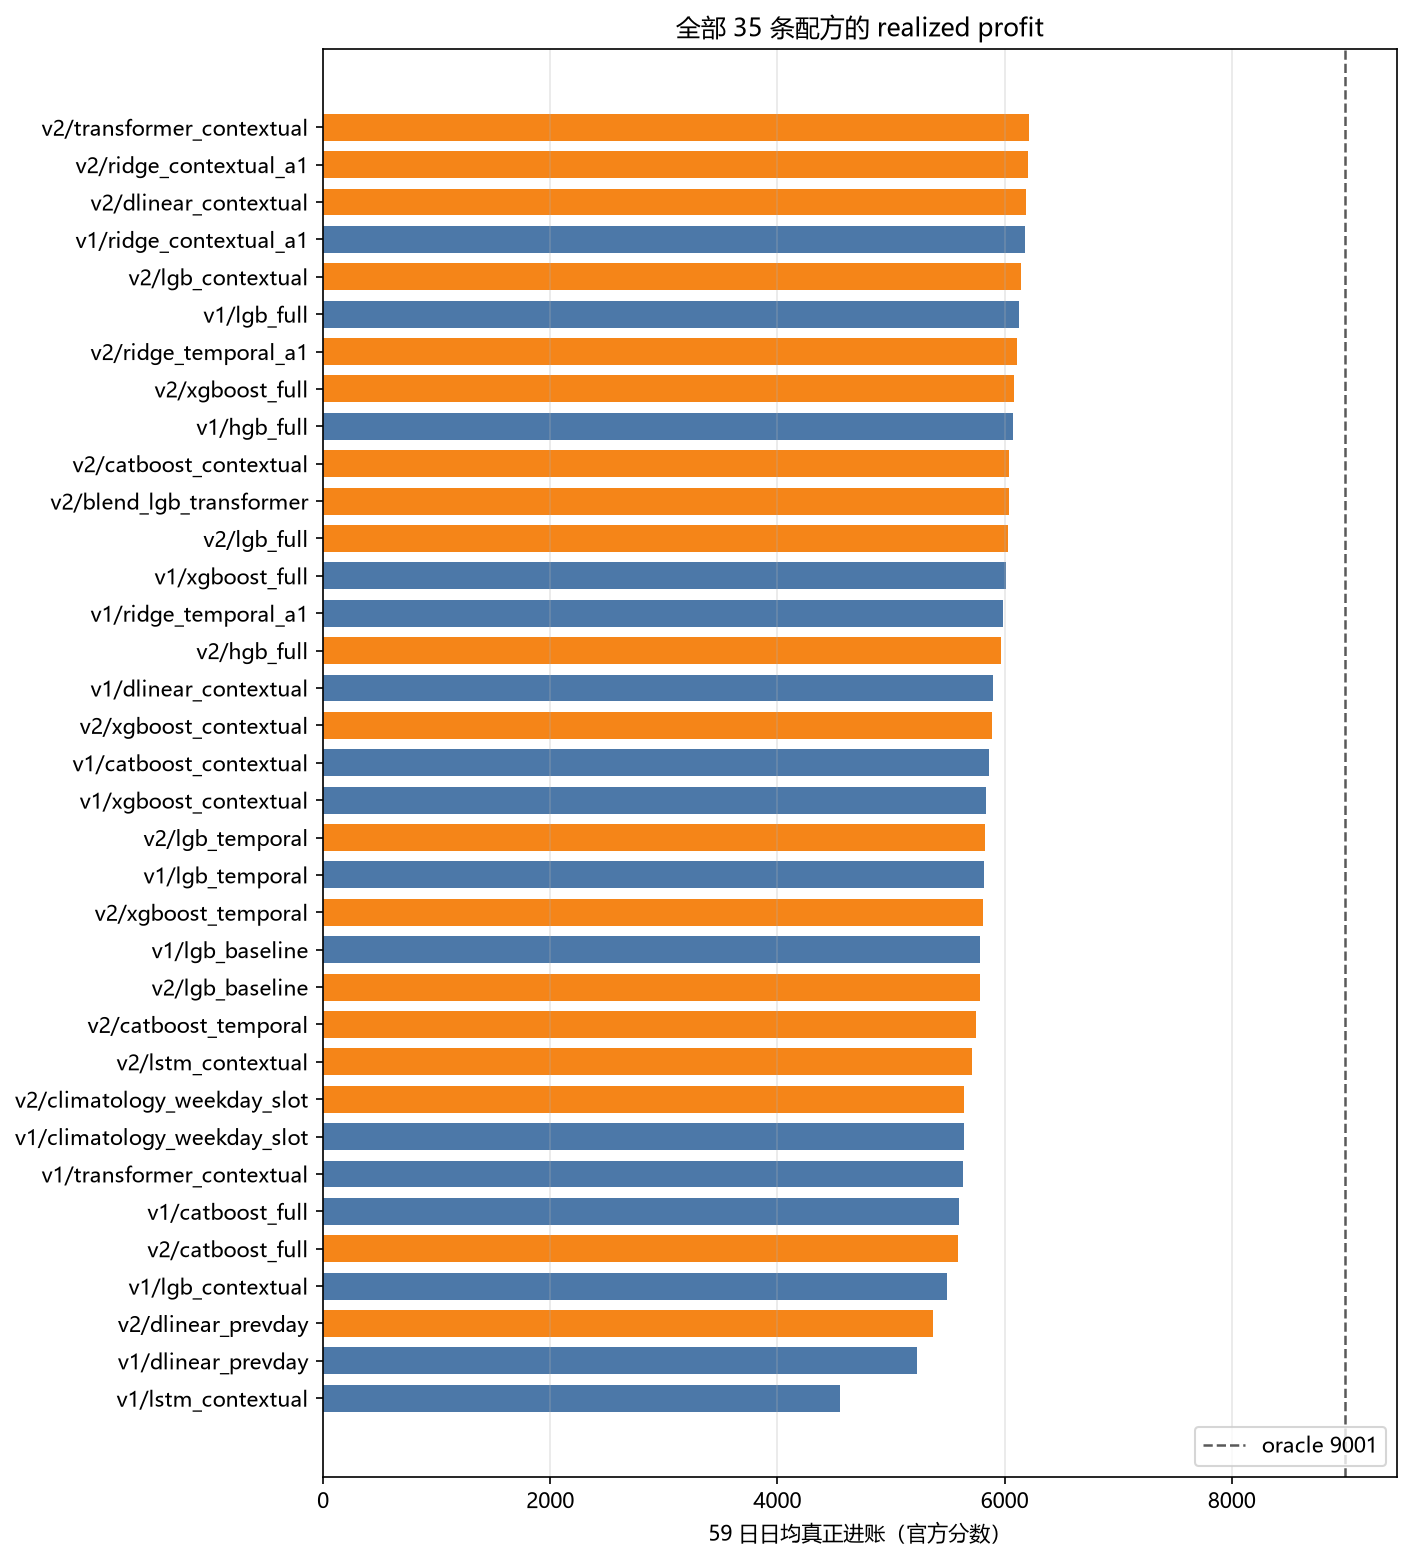

outputs\notebooks\figures\nb11_fig1_realized_bar.png


In [4]:
fig, ax = plt.subplots(figsize=(9.5, 10.5))
labels = board['recipe'].tolist()[::-1]
values = board['realized_profit_mean'].to_numpy()[::-1]
colors = ['#4C78A8' if item.startswith('v1/') else '#F58518' for item in labels]
ax.barh(labels, values, color=colors, height=0.72)
ax.axvline(oracle, color='0.35', linestyle='--', linewidth=1.2, label=f'oracle {oracle:.0f}')
ax.set_xlabel('59 日日均真正进账（官方分数）')
ax.set_title('全部 35 条配方的 realized profit')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
p1 = FIGURES / 'nb11_fig1_realized_bar.png'
fig.savefig(p1, dpi=150, bbox_inches='tight')
plt.close(fig)
show_figure(p1)
print(p1.relative_to(REPO_ROOT))


## 3. RMSE 对真正进账

若 RMSE 是钱的代理，点应从左上走到右下。v1 反而略向右上：点越不准，钱略多。标出的四个名字是失败分析要用的锚。


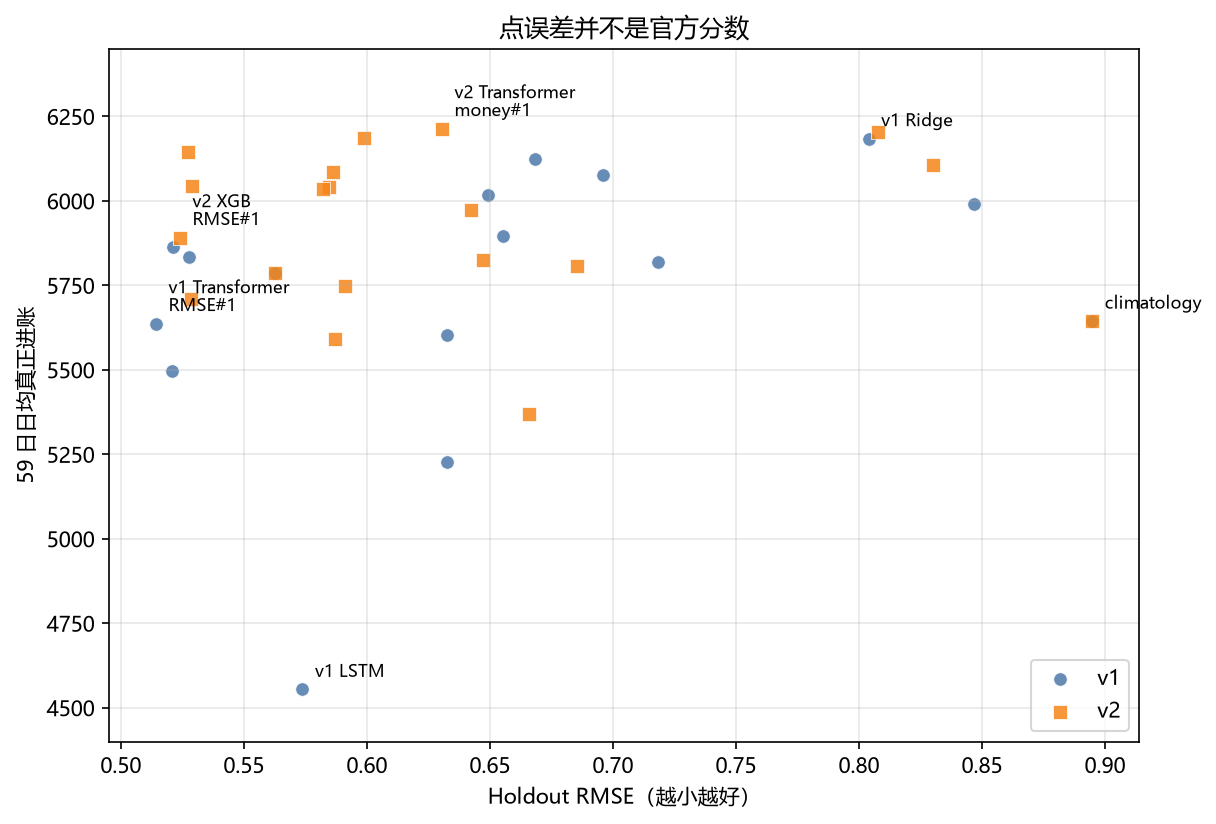

outputs\notebooks\figures\nb11_fig2_rmse_vs_realized.png


In [5]:
fig, ax = plt.subplots(figsize=(8.2, 5.6))
for version, color, marker in (('v1', '#4C78A8', 'o'), ('v2', '#F58518', 's')):
    slice_ = board.loc[board['version'] == version]
    ax.scatter(
        slice_['RMSE'],
        slice_['realized_profit_mean'],
        c=color,
        marker=marker,
        s=42,
        alpha=0.85,
        label=version,
        edgecolors='white',
        linewidths=0.4,
    )
annotate = {
    'v1/transformer_contextual': 'v1 Transformer\nRMSE#1',
    'v2/transformer_contextual': 'v2 Transformer\nmoney#1',
    'v1/ridge_contextual_a1': 'v1 Ridge',
    'v1/lstm_contextual': 'v1 LSTM',
    'v1/climatology_weekday_slot': 'climatology',
    'v2/xgboost_contextual': 'v2 XGB\nRMSE#1',
}
for recipe, text in annotate.items():
    row = board.loc[board['recipe'] == recipe].iloc[0]
    ax.annotate(
        text,
        (row['RMSE'], row['realized_profit_mean']),
        textcoords='offset points',
        xytext=(6, 6),
        fontsize=8,
    )
ax.set_xlabel('Holdout RMSE（越小越好）')
ax.set_ylabel('59 日日均真正进账')
ax.set_title('点误差并不是官方分数')
ax.set_ylim(4400, 6450)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
p2 = FIGURES / 'nb11_fig2_rmse_vs_realized.png'
fig.savefig(p2, dpi=150, bbox_inches='tight')
plt.close(fig)
show_figure(p2)
print(p2.relative_to(REPO_ROOT))


## 4. Failure analysis：为什么 v1 Transformer 点准却赚得少

`optimize_day` 只看见 96 点预测，穷举 3321 个合法 8+8 窗，然后 **锁死** power。RMSE 平均全部 96 点；钱只取决于最便宜的 8 格和最贵的 8 格排得对不对、差得够不够大。

**Capture 不是第二个模型。** 表上的 capture = 日均 realized / 日均 oracle，等价于总进账 / 总上界。它也不是每天 capture 再平均：v1 Transformer 日均 capture 0.57，表上 0.63，因为 12-30 那天窗几乎对上，进账 31241。


In [6]:
focus_order = [
    ('v1', 'transformer_contextual'),
    ('v2', 'transformer_contextual'),
    ('v1', 'ridge_contextual_a1'),
    ('v1', 'lstm_contextual'),
]
focus_map = {(row['version'], row['model']): row for row in failure['focus']}
rows = []
for version, name in focus_order:
    item = focus_map[(version, name)]
    rows.append({
        '配方': f'{version}/{name}',
        'RMSE': item['RMSE'],
        '真正进账': item['realized_profit_mean'],
        '以为能赚': item['pred_profit_mean'],
        '乐观缺口': item['profit_gap'],
        'capture': item['capture'],
        '预测日较差/真较差': item['spread_ratio'],
        'Spearman': item['mean_spearman'],
        '充电窗偏了几格': item['mean_abs_charge_slots'],
        'capture<0.5天数': item['days_capture_below_0_5'],
        '亏钱天数': item['negative_days'],
    })
focus_frame = pd.DataFrame(rows)
display(
    focus_frame.style.format({
        'RMSE': '{:.3f}',
        '真正进账': '{:.1f}',
        '以为能赚': '{:.1f}',
        '乐观缺口': '{:.1f}',
        'capture': '{:.3f}',
        '预测日较差/真较差': '{:.2f}',
        'Spearman': '{:.2f}',
        '充电窗偏了几格': '{:.1f}',
    }).hide(axis='index')
)


配方,RMSE,真正进账,以为能赚,乐观缺口,capture,预测日较差/真较差,Spearman,充电窗偏了几格,capture<0.5天数,亏钱天数
v1/transformer_contextual,0.514,5637.2,6627.1,989.9,0.626,0.66,0.61,19.8,22,4
v2/transformer_contextual,0.631,6214.4,10526.9,4312.5,0.690,0.93,0.71,17.2,15,2
v1/ridge_contextual_a1,0.804,6184.4,10503.2,4318.8,0.687,1.02,0.70,18.1,15,1
v1/lstm_contextual,0.574,4554.4,6349.9,1795.5,0.506,0.62,0.50,19.9,26,8


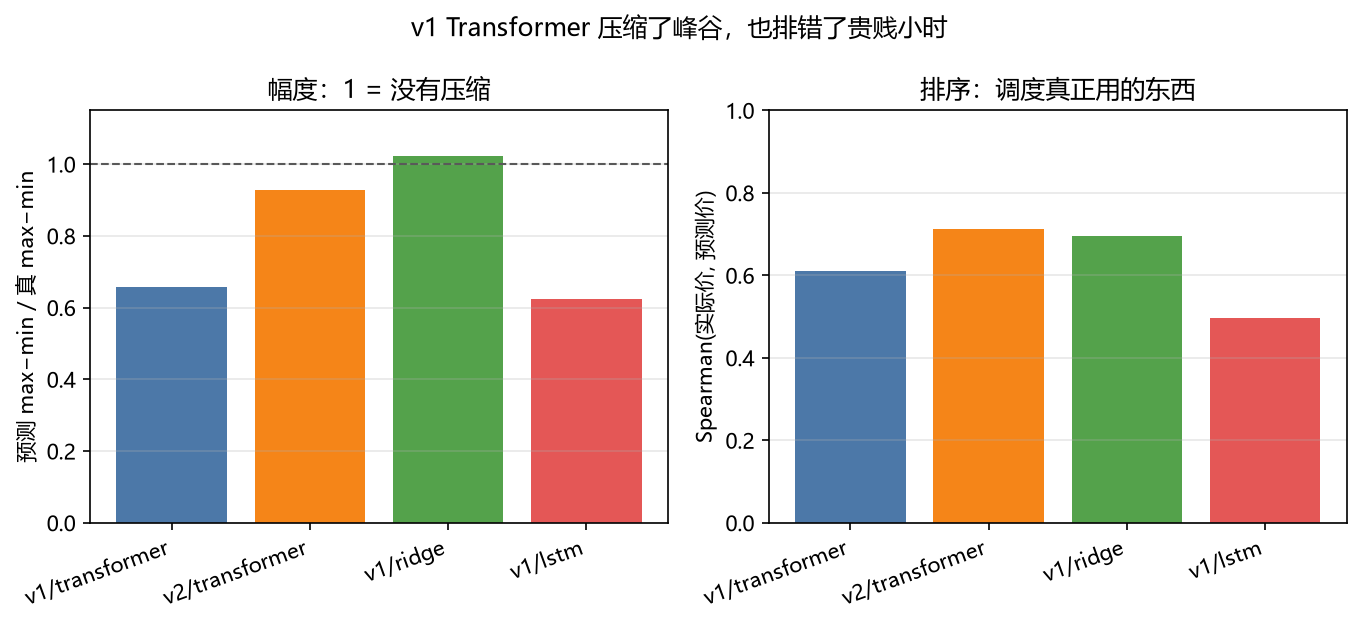

outputs\notebooks\figures\nb11_fig3_spread_spearman.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))
names = focus_frame['配方'].str.replace('_contextual', '', regex=False).str.replace('_a1', '', regex=False)
x = np.arange(len(names))
axes[0].bar(x, focus_frame['预测日较差/真较差'], color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[0].axhline(1.0, color='0.35', linestyle='--', linewidth=1)
axes[0].set_xticks(x, names, rotation=20, ha='right')
axes[0].set_ylabel('预测 max−min / 真 max−min')
axes[0].set_title('幅度：1 = 没有压缩')
axes[0].set_ylim(0, 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(x, focus_frame['Spearman'], color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_xticks(x, names, rotation=20, ha='right')
axes[1].set_ylabel('Spearman(实际价, 预测价)')
axes[1].set_title('排序：调度真正用的东西')
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', alpha=0.3)
fig.suptitle('v1 Transformer 压缩了峰谷，也排错了贵贱小时')
fig.tight_layout()
p3 = FIGURES / 'nb11_fig3_spread_spearman.png'
fig.savefig(p3, dpi=150, bbox_inches='tight')
plt.close(fig)
show_figure(p3)
print(p3.relative_to(REPO_ROOT))


三条机制（同一套 59 条预测曲线）：

1. **幅度收缩。** v1 Transformer 预测日较差只有真值的 66%。`optimize_day` 看见的峰谷差太小，以为能赚只有 6627（Ridge 是 10503）。乐观缺口只有 990：它对「自己很小」是诚实的，错的是窗的位置。
2. **付钱的 16 格排序差。** Spearman 0.61，对照 Ridge / v2 Transformer 的 0.70+。oracle 那 16 格 RMSE 0.52，其余 80 格 0.41——准确度花在平静时段上了。
3. **窗偏离约 5 小时。** 59 天零次精确 `(tc, td)` 命中并不稀奇（3321 个格子）；充电起点平均偏 20 格（约 5 小时）才是问题。

v2 Transformer 用 30 天停训后多跑了一些 epoch：RMSE 变差，是因为曲线不再死贴均值；幅度回到 0.93、Spearman 升到 0.71，于是变成全场进账第一。同一架构，两种训练，钱完全相反。v1 LSTM 是同一类失败更狠（幅度 0.62，8 天亏钱，capture 0.51）。Ridge 是反面：点很歪，但便宜/贵的小时顺序还能用。


## 5. 两天对照：12-12 坐错窗，12-30 撞上尖峰

阴影是 v1 Transformer 锁死的充（蓝）/放（红）8 格；细线是当天真实 `A`，粗虚线是它的 \(\hat p\)。


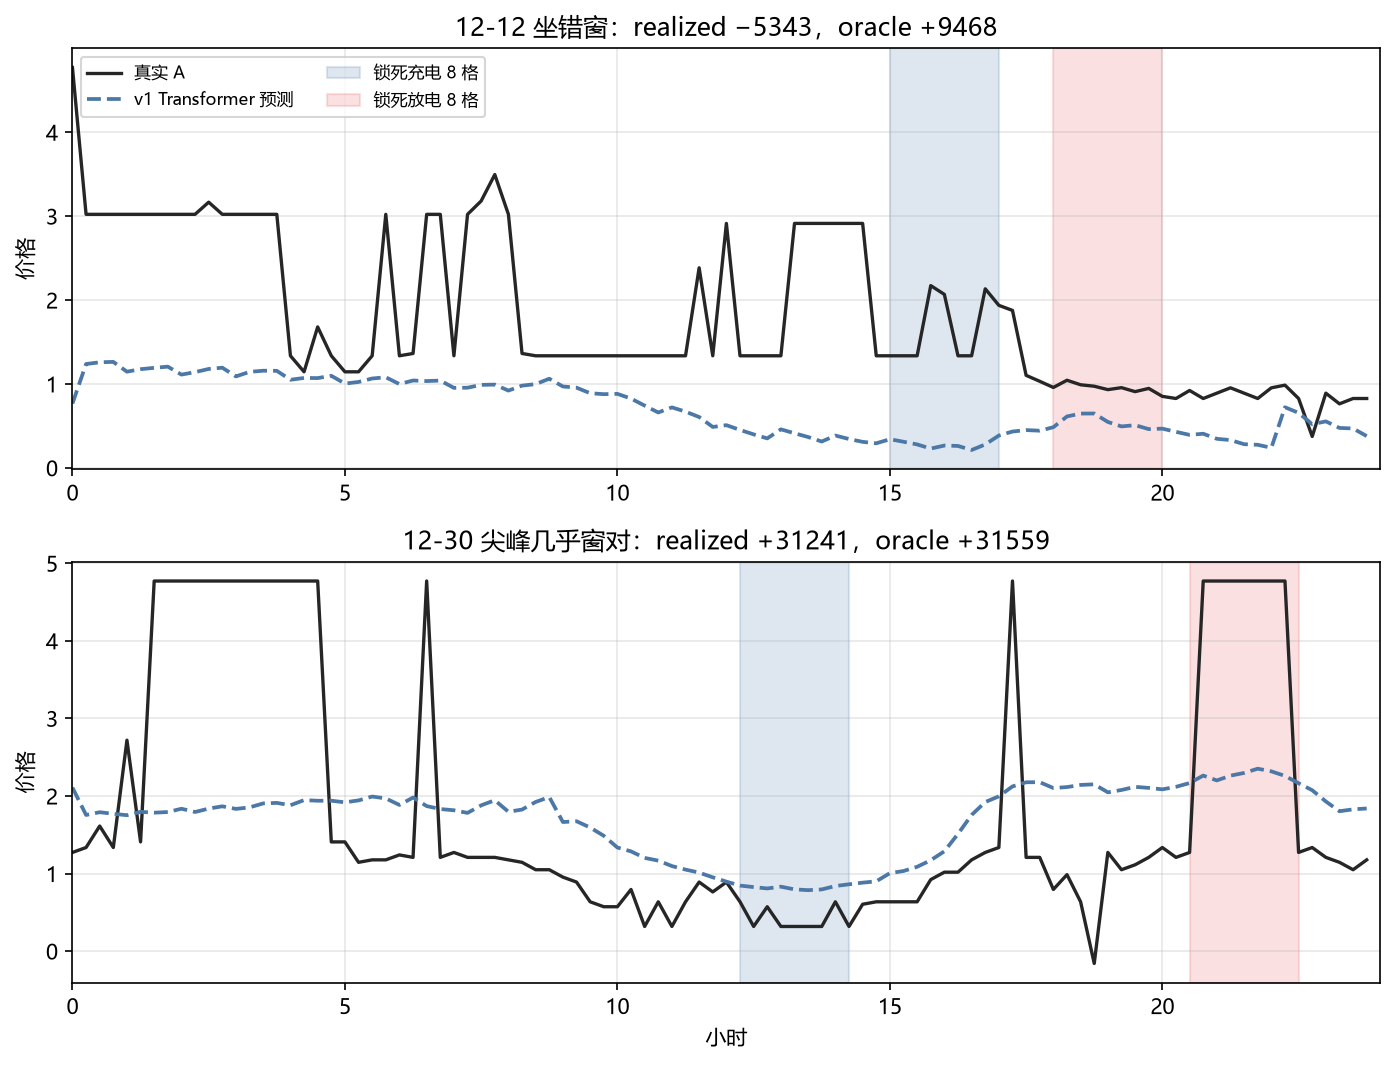

v1 Transformer 59 日均 5637.2；去掉 12-30 后 58 日均 5195.7
outputs\notebooks\figures\nb11_fig4_two_days.png


In [8]:
from src.phase_b.contracts import BLOCK_STEPS, STEPS_PER_DAY

pred = pd.read_parquet(V1 / 'predictions.parquet')
pred['times'] = pd.to_datetime(pred['times'])
pred['date'] = pred['times'].dt.normalize()
daily = pd.read_csv(V1 / 'dispatch_daily.csv')
daily['date'] = pd.to_datetime(daily['date']).dt.normalize()
tr_daily = daily.loc[daily['model'] == 'transformer_contextual'].set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(9.4, 7.2), sharex=False)
cases = [
    (pd.Timestamp('2025-12-12'), '12-12 坐错窗：realized −5343，oracle +9468'),
    (pd.Timestamp('2025-12-30'), '12-30 尖峰几乎窗对：realized +31241，oracle +31559'),
]
hours = np.arange(STEPS_PER_DAY) / 4.0
for ax, (day, title) in zip(axes, cases):
    day_frame = pred.loc[pred['date'] == day]
    actual = day_frame['A'].to_numpy()
    hat = day_frame['transformer_contextual'].to_numpy()
    row = tr_daily.loc[day]
    tc, td = int(row['tc']), int(row['td'])
    ax.plot(hours, actual, color='0.15', lw=1.6, label='真实 A')
    ax.plot(hours, hat, color='#4C78A8', lw=1.8, ls='--', label='v1 Transformer 预测')
    ax.axvspan(tc / 4.0, (tc + BLOCK_STEPS) / 4.0, color='#4C78A8', alpha=0.18, label='锁死充电 8 格')
    ax.axvspan(td / 4.0, (td + BLOCK_STEPS) / 4.0, color='#E45756', alpha=0.18, label='锁死放电 8 格')
    ax.set_title(title)
    ax.set_ylabel('价格')
    ax.set_xlim(0, 24)
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].set_xlabel('小时')
fig.tight_layout()
p4 = FIGURES / 'nb11_fig4_two_days.png'
fig.savefig(p4, dpi=150, bbox_inches='tight')
plt.close(fig)
show_figure(p4)

without = tr_daily.drop(index=pd.Timestamp('2025-12-30'))['realized_profit'].mean()
print(
    f"v1 Transformer 59 日均 {tr_daily['realized_profit'].mean():.1f}；"
    f"去掉 12-30 后 58 日均 {without:.1f}"
)
print(p4.relative_to(REPO_ROOT))


## 6. 读列的逻辑，以及下一步不该做什么

- RMSE 小只说明点准；`pred_profit` 高只说明在自己的 \(\hat p\) 上穷举很赚；**`realized_profit` 才是回放成绩**。
- `profit_gap` 大 = 对峰谷太乐观。`capture` 低 = 相对真价最优窗，钱留得少。两者都可以差，也可以一个好一个坏。
- 不要用这 59 天的利润重训、重选、或改 `optimize_day`。有用的下一问是：一个保住峰谷排序和幅度的头，会不会在**尚未用来排 RMSE 的切片**上打败「死磕 96 点 RMSE」的头。
